In [3]:
!pip install xgboost lightgbm imbalanced-learn optuna

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/fetal-health-classification/fetal_health.csv


In [ ]:
import warnings
warnings.simplefilter(action="ignore")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

from imblearn.combine import SMOTETomek

import xgboost as xgb
import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler
import pickle

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
# 1. LOAD & EXPLORE

df = pd.read_csv("/kaggle/input/fetal-health-classification/fetal_health.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nClass Distribution:")
print(df["fetal_health"].value_counts())
print("\nClass Distribution (%):")
print(df["fetal_health"].value_counts(normalize=True).round(3) * 100)
print("\nMissing Values:", df.isnull().sum().sum())
print("\nFeature Stats:")
print(df.describe())

Dataset Shape: (2126, 22)

First 5 rows:
   baseline value  accelerations  fetal_movement  uterine_contractions  \
0           120.0          0.000             0.0                 0.000   
1           132.0          0.006             0.0                 0.006   
2           133.0          0.003             0.0                 0.008   
3           134.0          0.003             0.0                 0.008   
4           132.0          0.007             0.0                 0.008   

   light_decelerations  severe_decelerations  prolongued_decelerations  \
0                0.000                   0.0                       0.0   
1                0.003                   0.0                       0.0   
2                0.003                   0.0                       0.0   
3                0.003                   0.0                       0.0   
4                0.000                   0.0                       0.0   

   abnormal_short_term_variability  mean_value_of_short_term_variabil

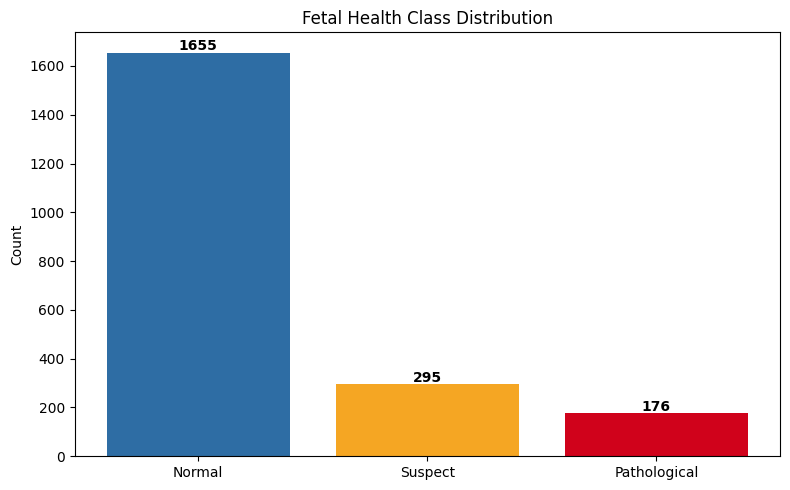

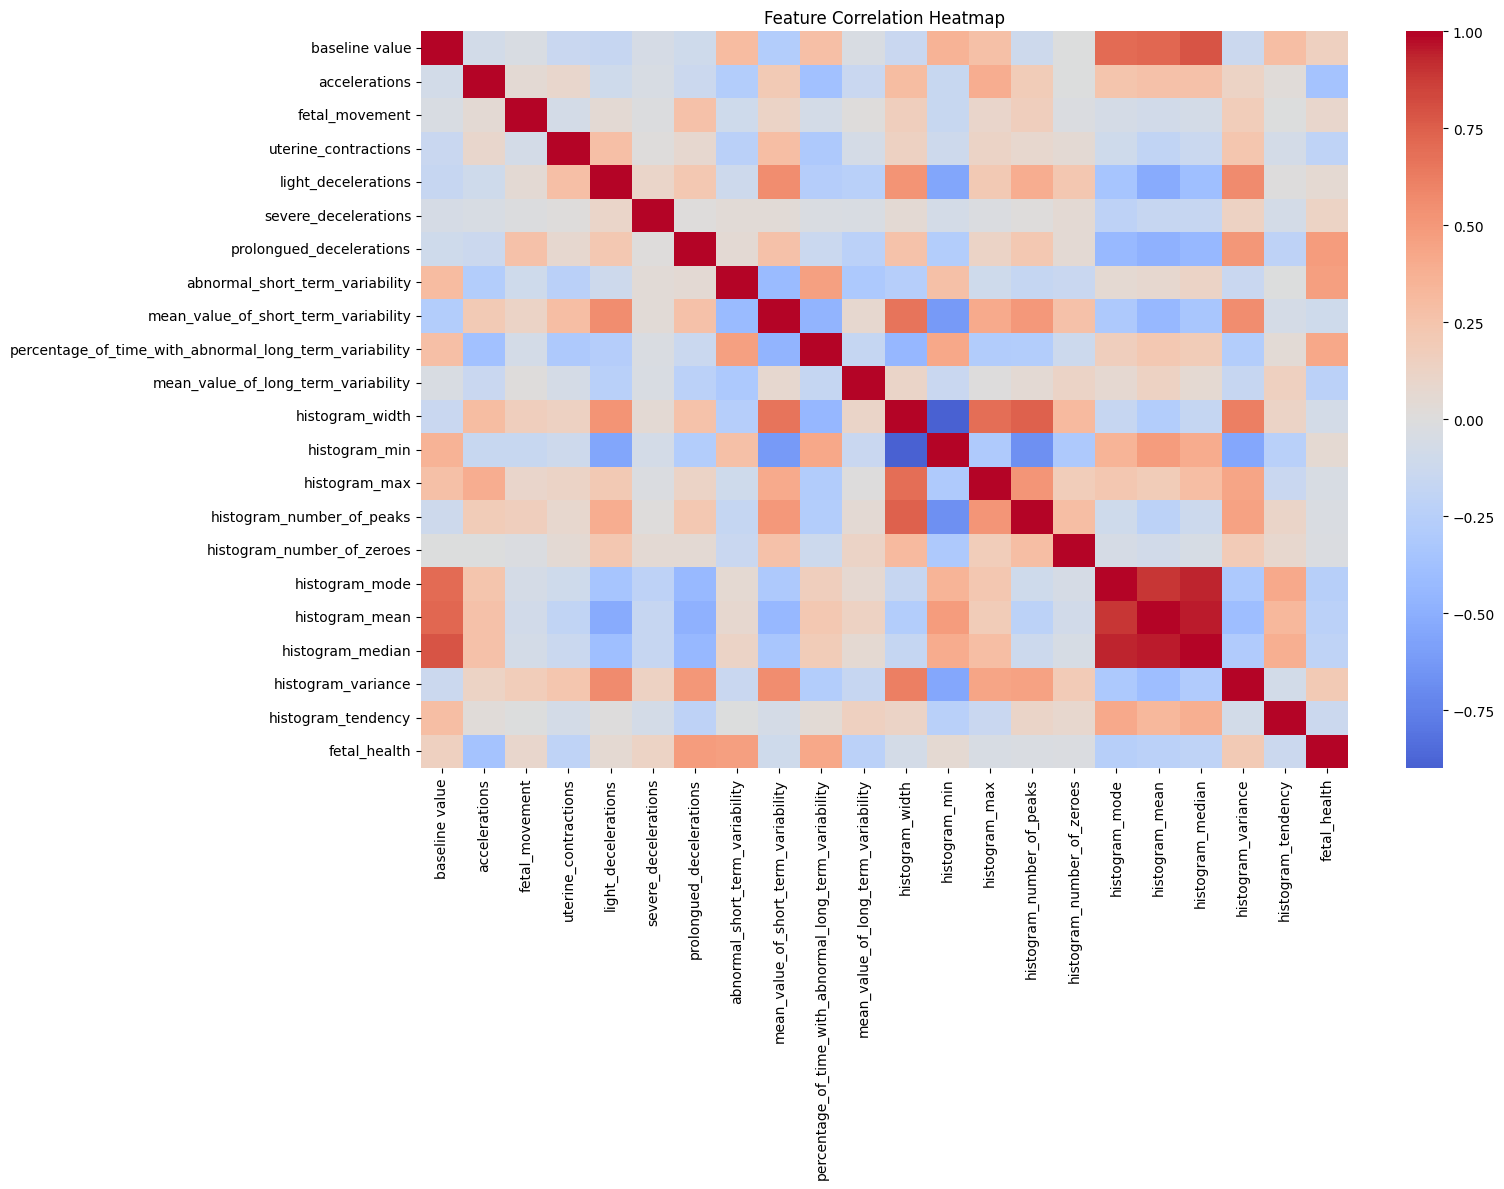

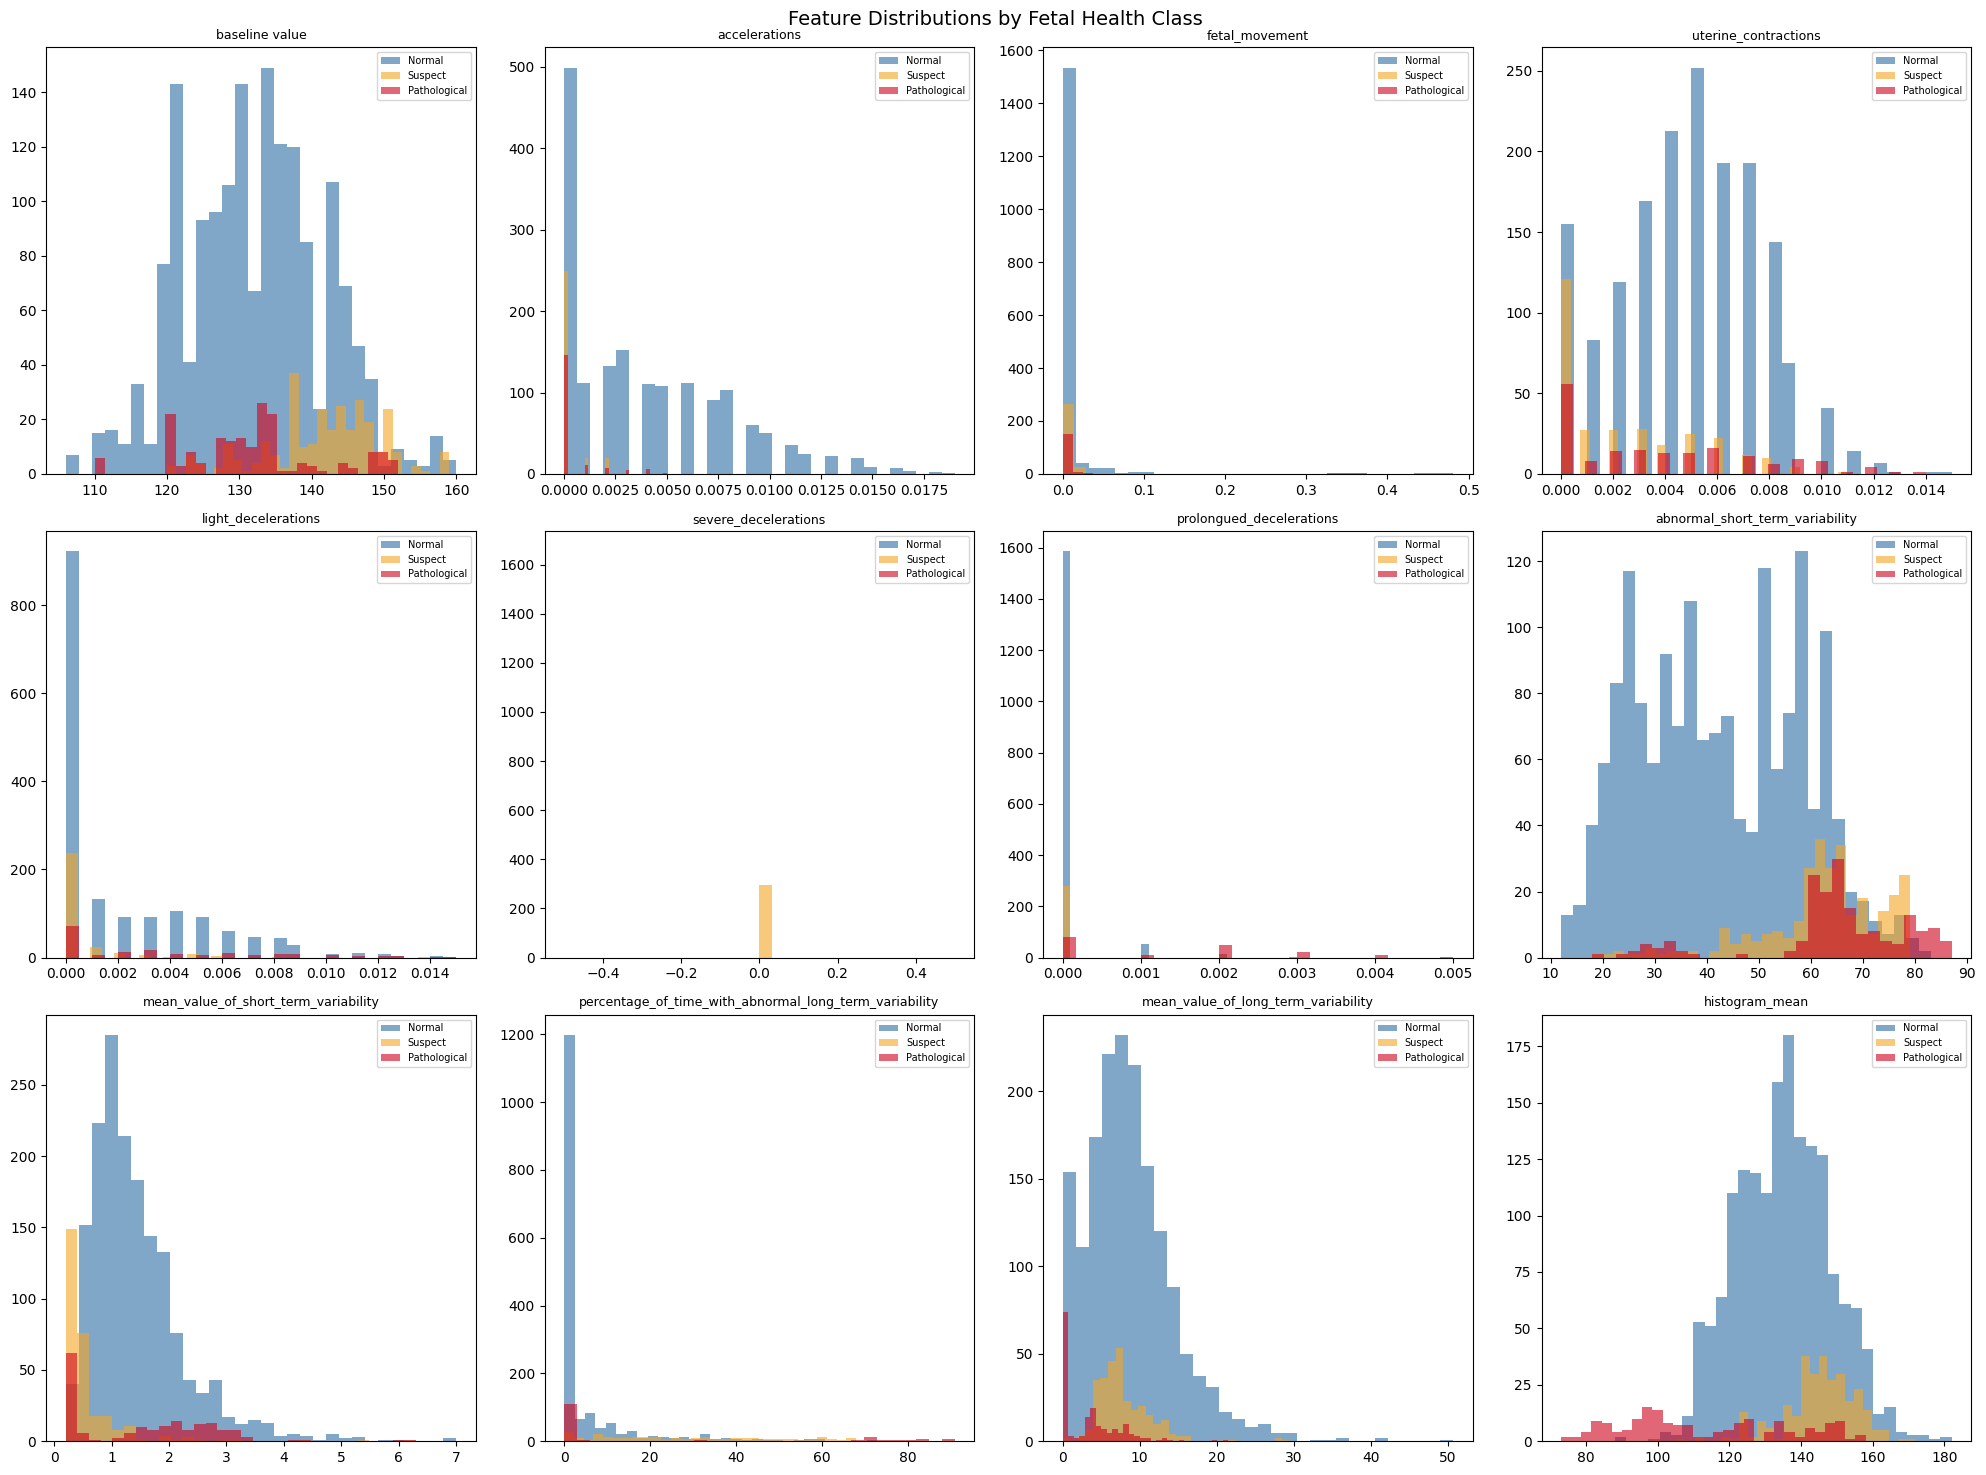

In [ ]:
# 2. EDA VISUALIZATIONS

# Class distribution
plt.figure(figsize=(8, 5))
class_names = {1.0: "Normal", 2.0: "Suspect", 3.0: "Pathological"}
counts = df["fetal_health"].value_counts().sort_index()
colors = ["#2E6DA4", "#F5A623", "#D0021B"]
plt.bar([class_names[k] for k in counts.index], counts.values, color=colors)
plt.title("Fetal Health Class Distribution")
plt.ylabel("Count")
for i, v in enumerate(counts.values):
    plt.text(i, v + 10, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("fetal_class_distribution.png")
plt.show()

# Correlation heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("fetal_correlation_heatmap.png")
plt.show()

# Feature distributions by class
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
top_features = [
    "baseline value", "accelerations", "fetal_movement",
    "uterine_contractions", "light_decelerations", "severe_decelerations",
    "prolongued_decelerations", "abnormal_short_term_variability",
    "mean_value_of_short_term_variability", "percentage_of_time_with_abnormal_long_term_variability",
    "mean_value_of_long_term_variability", "histogram_mean"
]
for ax, feat in zip(axes.flatten(), top_features):
    for cls, color, label in zip([1.0, 2.0, 3.0], colors, ["Normal", "Suspect", "Pathological"]):
        ax.hist(df[df["fetal_health"] == cls][feat], bins=30, alpha=0.6, color=color, label=label)
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=7)
plt.suptitle("Feature Distributions by Fetal Health Class", fontsize=14)
plt.tight_layout()
plt.savefig("fetal_feature_distributions.png")
plt.show()

In [ ]:
# 3. FEATURE DERIVATION

# Encode target first (1=Normal, 2=Suspect, 3=Pathological → 0,1,2)
df["fetal_health"] = df["fetal_health"] - 1
df["fetal_health"] = df["fetal_health"].astype(int)

# --- Deceleration Features ---
df["TotalDecelerations"]     = (df["light_decelerations"] +
                                df["severe_decelerations"] +
                                df["prolongued_decelerations"])
df["SevereDecelFlag"]        = (df["severe_decelerations"] > 0).astype(int)
df["ProlongedDecelFlag"]     = (df["prolongued_decelerations"] > 0).astype(int)
df["DecelerationRatio"]      = df["severe_decelerations"] / (df["light_decelerations"] + 1e-6)

# --- Variability Features ---
df["VariabilityRatio"]       = (df["abnormal_short_term_variability"] /
                                (df["mean_value_of_short_term_variability"] + 1e-6))
df["LongTermVariabilityHigh"]= (df["percentage_of_time_with_abnormal_long_term_variability"] > 50).astype(int)
df["VariabilityStress"]      = (df["abnormal_short_term_variability"] *
                                df["percentage_of_time_with_abnormal_long_term_variability"])

# --- Heart Rate Features ---
df["TachycardiaFlag"]        = (df["baseline value"] > 160).astype(int)
df["BradycardiaFlag"]        = (df["baseline value"] < 110).astype(int)
df["AccelDecelRatio"]        = df["accelerations"] / (df["TotalDecelerations"] + 1e-6)
df["AccelFlag"]              = (df["accelerations"] > 0.003).astype(int)

# --- Histogram Features ---
df["HistogramSkewness"]      = df["histogram_max"] - df["histogram_min"]
df["HistogramModeOffset"]    = abs(df["histogram_mode"] - df["histogram_mean"])
df["HistogramSymmetry"]      = (df["histogram_mean"] / (df["histogram_mode"] + 1e-6))

# --- Combined Risk Score ---
df["FetalRiskScore"]         = (df["SevereDecelFlag"] +
                                df["ProlongedDecelFlag"] +
                                df["LongTermVariabilityHigh"] +
                                df["TachycardiaFlag"] +
                                df["BradycardiaFlag"])

# --- Contraction-Response Features ---
df["ContractionAccelResponse"]  = df["accelerations"] / (df["uterine_contractions"] + 1e-6)
df["ContractionDecelResponse"]  = df["TotalDecelerations"] / (df["uterine_contractions"] + 1e-6)
df["MovementAccelRatio"]        = df["fetal_movement"] / (df["accelerations"] + 1e-6)

print(f"\nTotal features after engineering: {df.shape[1] - 1}")
print(f"Original features: 21")
print(f"Engineered features: {df.shape[1] - 1 - 21}")


Total features after engineering: 39
Original features: 21
Engineered features: 18


In [ ]:
# 4. CORRECT ORDER: SPLIT → SCALE → SMOTETomek

feature_cols = [col for col in df.columns if col != "fetal_health"]
X = df[feature_cols]
y = df["fetal_health"]

# STEP 1 — Split first 
X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain size: {X_train_raw.shape[0]}")
print(f"Test size:  {X_test_raw.shape[0]}")
print(f"\nTrain class distribution:\n{y_train_raw.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")

# STEP 2 — Fit scaler on train only 
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_raw), columns=feature_cols
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_raw), columns=feature_cols
)

# STEP 3 — SMOTETomek on train only 
print("\nApplying SMOTETomek...")
smt = SMOTETomek(random_state=42)
X_train_smt, y_train_smt = smt.fit_resample(X_train_scaled, y_train_raw)

print(f"Before SMOTETomek: {X_train_scaled.shape}")
print(f"After SMOTETomek:  {X_train_smt.shape}")
print(f"Class distribution after:\n{pd.Series(y_train_smt).value_counts()}")

cv5  = StratifiedKFold(n_splits=5,  shuffle=True, random_state=42)
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


Train size: 1700
Test size:  426

Train class distribution:
fetal_health
0    1323
1     236
2     141
Name: count, dtype: int64

Test class distribution:
fetal_health
0    332
1     59
2     35
Name: count, dtype: int64

Applying SMOTETomek...
Before SMOTETomek: (1700, 39)
After SMOTETomek:  (3961, 39)
Class distribution after:
fetal_health
2    1322
0    1320
1    1319
Name: count, dtype: int64


In [ ]:
# 5. LightGBM

print("\n" + "="*55)
print("Optuna Tuning: LightGBM (100 trials)")
print("="*55)

def objective_lgb(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 600),
        "max_depth":         trial.suggest_int("max_depth", 3, 12),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 20, 100),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "reg_alpha":         trial.suggest_float("reg_alpha", 0, 1.0),
        "reg_lambda":        trial.suggest_float("reg_lambda", 0, 1.0),
    }
    model = lgb.LGBMClassifier(**params, random_state=42, verbose=-1, n_jobs=-1)
    score = cross_val_score(
        model, X_train_smt, y_train_smt, cv=cv5, scoring="accuracy"
    ).mean()
    return score

study_lgb = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_lgb.optimize(objective_lgb, n_trials=100, show_progress_bar=True)

lgb_best = lgb.LGBMClassifier(
    **study_lgb.best_params, random_state=42, verbose=-1, n_jobs=-1
)
lgb_best.fit(X_train_smt, y_train_smt)
pred_lgb = lgb_best.predict(X_test_scaled)
lgb_cv10 = cross_val_score(
    lgb_best, X_train_smt, y_train_smt, cv=cv10, scoring="accuracy"
)

print(f"\nLightGBM Test Score:       {round(accuracy_score(y_test, pred_lgb), 4)}")
print(f"LightGBM 10-Fold CV Score: {round(lgb_cv10.mean(), 4)}")
print(f"LightGBM Best Fold:        {round(lgb_cv10.max(), 4)}")
print(f"All folds: {[round(s, 4) for s in lgb_cv10]}")
print("\nClassification Report:")
print(classification_report(y_test, pred_lgb,
      target_names=["Normal", "Suspect", "Pathological"]))


Optuna Tuning: LightGBM (100 trials)


  0%|          | 0/100 [00:00<?, ?it/s]


LightGBM Test Score:       0.9366
LightGBM 10-Fold CV Score: 0.9861
LightGBM Best Fold:        0.9975
All folds: [np.float64(0.9798), np.float64(0.9798), np.float64(0.9798), np.float64(0.9975), np.float64(0.9798), np.float64(0.9874), np.float64(0.9949), np.float64(0.9924), np.float64(0.9823), np.float64(0.9874)]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.97      0.97       332
     Suspect       0.82      0.78      0.80        59
Pathological       0.84      0.89      0.86        35

    accuracy                           0.94       426
   macro avg       0.88      0.88      0.88       426
weighted avg       0.94      0.94      0.94       426



In [ ]:
# 6. XGBoost

print("\n" + "="*55)
print("Optuna Tuning: XGBoost (100 trials)")
print("="*55)

def objective_xgb(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 600),
        "max_depth":        trial.suggest_int("max_depth", 3, 12),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma":            trial.suggest_float("gamma", 0, 0.5),
        "reg_alpha":        trial.suggest_float("reg_alpha", 0, 1.0),
        "reg_lambda":       trial.suggest_float("reg_lambda", 0.5, 3.0),
    }
    model = xgb.XGBClassifier(
        **params, eval_metric="mlogloss", random_state=42, n_jobs=-1
    )
    score = cross_val_score(
        model, X_train_smt, y_train_smt, cv=cv5, scoring="accuracy"
    ).mean()
    return score

study_xgb = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=100, show_progress_bar=True)

xgb_best = xgb.XGBClassifier(
    **study_xgb.best_params, eval_metric="mlogloss", random_state=42, n_jobs=-1
)
xgb_best.fit(X_train_smt, y_train_smt)
pred_xgb = xgb_best.predict(X_test_scaled)
xgb_cv10 = cross_val_score(
    xgb_best, X_train_smt, y_train_smt, cv=cv10, scoring="accuracy"
)

print(f"\nXGBoost Test Score:       {round(accuracy_score(y_test, pred_xgb), 4)}")
print(f"XGBoost 10-Fold CV Score: {round(xgb_cv10.mean(), 4)}")
print(f"XGBoost Best Fold:        {round(xgb_cv10.max(), 4)}")
print(f"All folds: {[round(s, 4) for s in xgb_cv10]}")


Optuna Tuning: XGBoost (100 trials)


  0%|          | 0/100 [00:00<?, ?it/s]


XGBoost Test Score:       0.9296
XGBoost 10-Fold CV Score: 0.9833
XGBoost Best Fold:        0.9924
All folds: [np.float64(0.9723), np.float64(0.9798), np.float64(0.9798), np.float64(0.9924), np.float64(0.9798), np.float64(0.9823), np.float64(0.9924), np.float64(0.9874), np.float64(0.9798), np.float64(0.9874)]


In [ ]:
# 7. Random Forest

print("\n" + "="*55)
print("Optuna Tuning: Random Forest (80 trials)")
print("="*55)

def objective_rf(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 500),
        "max_depth":         trial.suggest_int("max_depth", 5, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 5),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "criterion":         trial.suggest_categorical("criterion", ["gini", "entropy"]),
    }
    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    score = cross_val_score(
        model, X_train_smt, y_train_smt, cv=cv5, scoring="accuracy"
    ).mean()
    return score

study_rf = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_rf.optimize(objective_rf, n_trials=80, show_progress_bar=True)

rf_best = RandomForestClassifier(**study_rf.best_params, random_state=42, n_jobs=-1)
rf_best.fit(X_train_smt, y_train_smt)
pred_rf = rf_best.predict(X_test_scaled)
rf_cv10 = cross_val_score(
    rf_best, X_train_smt, y_train_smt, cv=cv10, scoring="accuracy"
)

print(f"\nRF Test Score:       {round(accuracy_score(y_test, pred_rf), 4)}")
print(f"RF 10-Fold CV Score: {round(rf_cv10.mean(), 4)}")
print(f"RF Best Fold:        {round(rf_cv10.max(), 4)}")
print(f"All folds: {[round(s, 4) for s in rf_cv10]}")


Optuna Tuning: Random Forest (80 trials)


  0%|          | 0/80 [00:00<?, ?it/s]


RF Test Score:       0.939
RF 10-Fold CV Score: 0.9813
RF Best Fold:        0.9975
All folds: [np.float64(0.9773), np.float64(0.9823), np.float64(0.9697), np.float64(0.9773), np.float64(0.9798), np.float64(0.9823), np.float64(0.9975), np.float64(0.9823), np.float64(0.9773), np.float64(0.9874)]


In [ ]:
# 8. VOTING ENSEMBLE

print("\n" + "="*55)
print("Voting Ensemble: LightGBM + XGBoost + RF")
print("="*55)

voting_clf = VotingClassifier(
    estimators=[
        ("lgb", lgb_best),
        ("xgb", xgb_best),
        ("rf",  rf_best),
    ],
    voting="soft",
    weights=[2, 1, 1]
)
voting_clf.fit(X_train_smt, y_train_smt)
pred_voting = voting_clf.predict(X_test_scaled)
voting_cv10 = cross_val_score(
    voting_clf, X_train_smt, y_train_smt, cv=cv10, scoring="accuracy"
)

print(f"Voting Test Score:       {round(accuracy_score(y_test, pred_voting), 4)}")
print(f"Voting 10-Fold CV Score: {round(voting_cv10.mean(), 4)}")
print(f"Voting Best Fold:        {round(voting_cv10.max(), 4)}")
print("\nVoting Classification Report:")
print(classification_report(y_test, pred_voting,
      target_names=["Normal", "Suspect", "Pathological"]))


Voting Ensemble: LightGBM + XGBoost + RF
Voting Test Score:       0.9366
Voting 10-Fold CV Score: 0.9859
Voting Best Fold:        0.9975

Voting Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.97      0.97       332
     Suspect       0.82      0.78      0.80        59
Pathological       0.84      0.89      0.86        35

    accuracy                           0.94       426
   macro avg       0.88      0.88      0.88       426
weighted avg       0.94      0.94      0.94       426



In [ ]:
# 9. STACKING ENSEMBLE

print("\n" + "="*55)
print("Stacking Ensemble")
print("="*55)

stacking_clf = StackingClassifier(
    estimators=[
        ("lgb", lgb_best),
        ("xgb", xgb_best),
        ("rf",  rf_best),
    ],
    final_estimator=LogisticRegression(
        C=10, max_iter=1000, random_state=42
    ),
    cv=5,
    stack_method="predict_proba",
    n_jobs=-1
)
stacking_clf.fit(X_train_smt, y_train_smt)
pred_stacking = stacking_clf.predict(X_test_scaled)
stacking_cv10 = cross_val_score(
    stacking_clf, X_train_smt, y_train_smt, cv=cv10, scoring="accuracy"
)

print(f"Stacking Test Score:       {round(accuracy_score(y_test, pred_stacking), 4)}")
print(f"Stacking 10-Fold CV Score: {round(stacking_cv10.mean(), 4)}")
print(f"Stacking Best Fold:        {round(stacking_cv10.max(), 4)}")


Stacking Ensemble
Stacking Test Score:       0.9413
Stacking 10-Fold CV Score: 0.9849
Stacking Best Fold:        0.9949


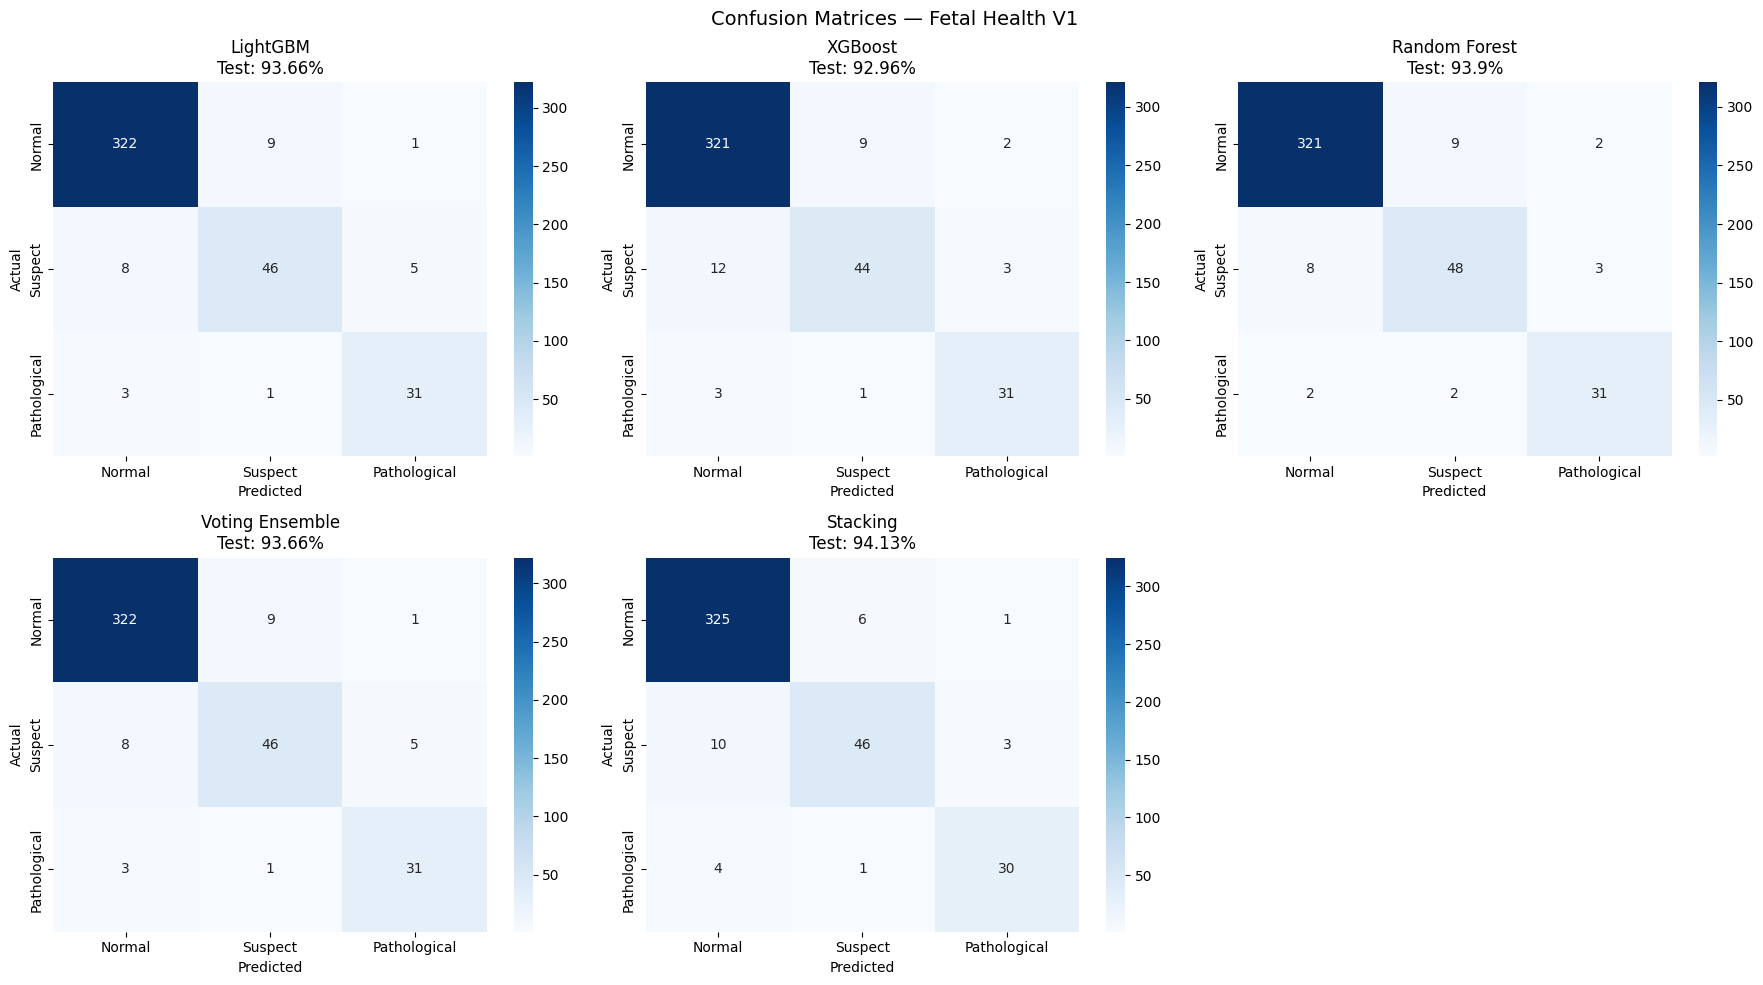

In [ ]:
# 10. CONFUSION MATRICES

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
models_cm = {
    "LightGBM":        pred_lgb,
    "XGBoost":         pred_xgb,
    "Random Forest":   pred_rf,
    "Voting Ensemble": pred_voting,
    "Stacking":        pred_stacking,
}
for ax, (name, pred) in zip(axes.flatten(), models_cm.items()):
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt="d",
                cmap="Blues", ax=ax)
    ax.set_title(f"{name}\nTest: {round(accuracy_score(y_test, pred)*100, 2)}%")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.xaxis.set_ticklabels(["Normal", "Suspect", "Pathological"])
    ax.yaxis.set_ticklabels(["Normal", "Suspect", "Pathological"])

axes[1][2].set_visible(False)
plt.suptitle("Confusion Matrices — Fetal Health V1", fontsize=14)
plt.tight_layout()
plt.savefig("fetal_confusion_matrices.png")
plt.show()

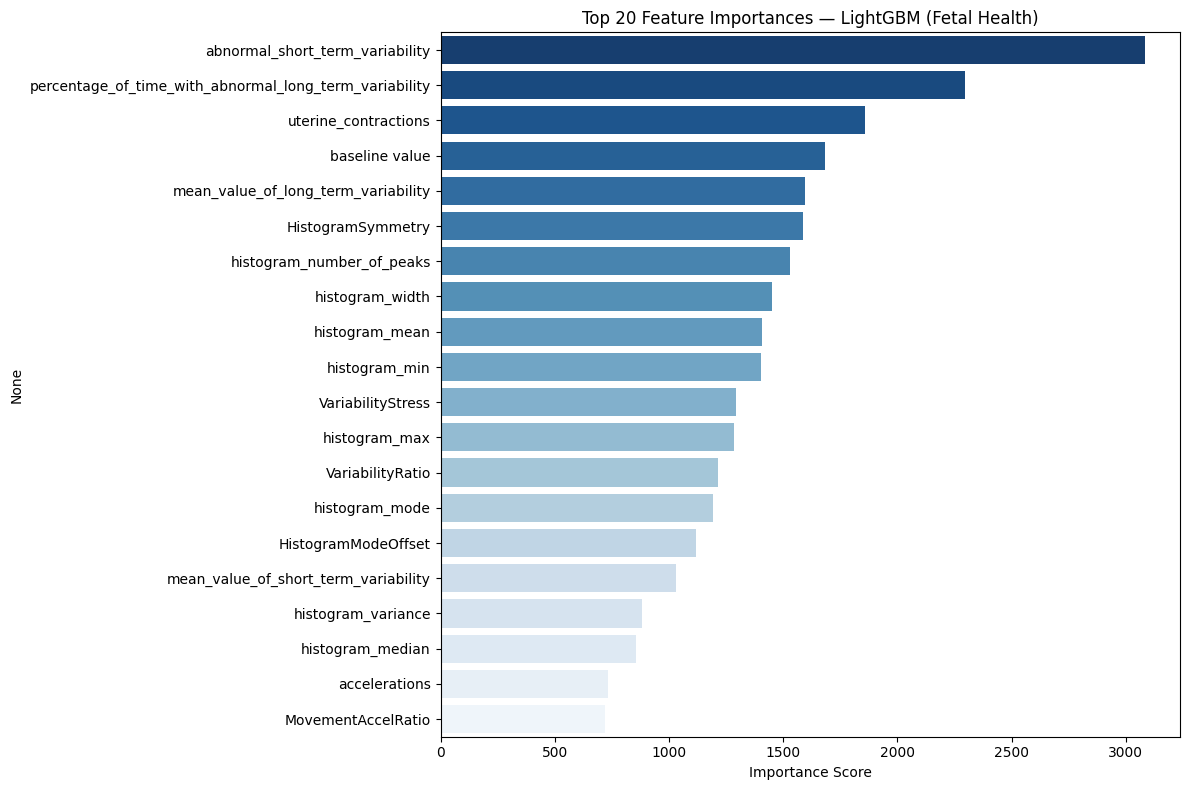

In [ ]:
# 11. FEATURE IMPORTANCE

lgb_imp = pd.Series(
    lgb_best.feature_importances_, index=feature_cols
).sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x=lgb_imp.values, y=lgb_imp.index, palette="Blues_r")
plt.title("Top 20 Feature Importances — LightGBM (Fetal Health)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("fetal_feature_importance.png")
plt.show()


FINAL MODEL COMPARISON — Fetal Health V1
          Model  Test Score  10-Fold CV Score  Best Fold  Precision  Recall  F1 Score
       Stacking      0.9413            0.9849     0.9949     0.9399  0.9413    0.9402
  Random Forest      0.9390            0.9813     0.9975     0.9392  0.9390    0.9391
       LightGBM      0.9366            0.9861     0.9975     0.9362  0.9366    0.9363
Voting Ensemble      0.9366            0.9859     0.9975     0.9362  0.9366    0.9363
        XGBoost      0.9296            0.9833     0.9924     0.9281  0.9296    0.9286


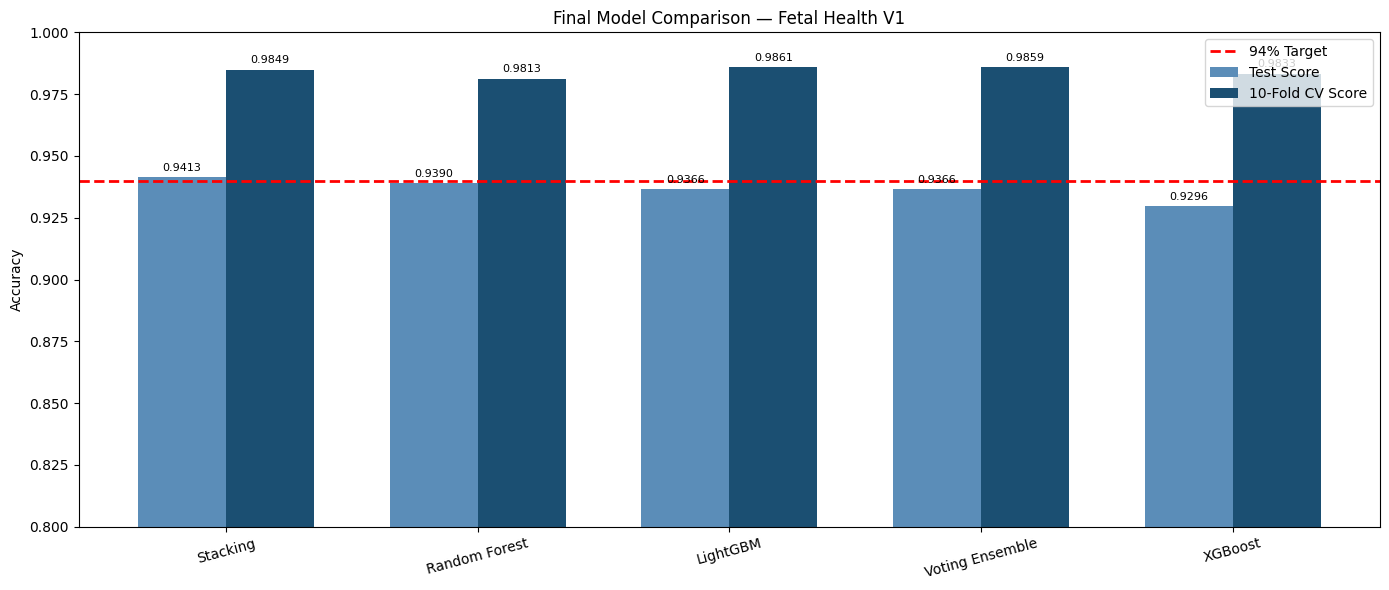

In [ ]:
# 12. FINAL COMPARISON TABLE

print("\n" + "="*60)
print("FINAL MODEL COMPARISON — Fetal Health V1")
print("="*60)

all_models = {
    "LightGBM":        (pred_lgb,      lgb_cv10),
    "XGBoost":         (pred_xgb,      xgb_cv10),
    "Random Forest":   (pred_rf,       rf_cv10),
    "Voting Ensemble": (pred_voting,   voting_cv10),
    "Stacking":        (pred_stacking, stacking_cv10),
}

results = []
for name, (pred, cv10_scores) in all_models.items():
    p, r, f, _ = precision_recall_fscore_support(y_test, pred, average="weighted")
    results.append({
        "Model":            name,
        "Test Score":       round(accuracy_score(y_test, pred), 4),
        "10-Fold CV Score": round(cv10_scores.mean(), 4),
        "Best Fold":        round(cv10_scores.max(), 4),
        "Precision":        round(p, 4),
        "Recall":           round(r, 4),
        "F1 Score":         round(f, 4),
    })

results_df = pd.DataFrame(results).sort_values("Test Score", ascending=False)
print(results_df.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(results_df))
width = 0.35
bars1 = ax.bar(x - width/2, results_df["Test Score"],
               width, label="Test Score", color="#5B8DB8")
bars2 = ax.bar(x + width/2, results_df["10-Fold CV Score"],
               width, label="10-Fold CV Score", color="#1B4F72")
ax.axhline(y=0.94, color="red", linestyle="--", linewidth=2, label="94% Target")
ax.set_xticks(x)
ax.set_xticklabels(results_df["Model"], rotation=15)
ax.set_ylim(0.80, 1.0)
ax.set_ylabel("Accuracy")
ax.set_title("Final Model Comparison — Fetal Health V1")
ax.bar_label(bars1, fmt="%.4f", padding=3, fontsize=8)
ax.bar_label(bars2, fmt="%.4f", padding=3, fontsize=8)
ax.legend()
plt.tight_layout()
plt.savefig("fetal_final_comparison.png")
plt.show()

In [ ]:
# 13. SAVE BEST MODEL

best_name = results_df.iloc[0]["Model"]
model_map = {
    "LightGBM":        lgb_best,
    "XGBoost":         xgb_best,
    "Random Forest":   rf_best,
    "Voting Ensemble": voting_clf,
    "Stacking":        stacking_clf,
}
best_model = model_map[best_name]

pickle.dump(best_model, open("finalized_fetal_model_v1.sav", "wb"))
pickle.dump(scaler,     open("fetal_scaler_v1.sav", "wb"))

print(f"\nBest model ({best_name}) saved!")
print(f"Scaler saved!")
print(f"\nFetal Health V1 Complete!")
print(f"Best Test Accuracy: {results_df.iloc[0]['Test Score']*100:.2f}%")


Best model (Stacking) saved!
Scaler saved!

Fetal Health V1 Complete!
Best Test Accuracy: 94.13%


In [19]:
from sklearn.metrics import accuracy_score

print("="*55)
print("OVERFITTING DIAGNOSTIC — Fetal Health V1")
print("="*55)
print(f"{'Model':<20} {'Train Acc':>10} {'Test Acc':>10} {'Gap':>8} {'Verdict':>15}")
print("="*55)

models_diag = {
    "LightGBM":      (lgb_best,      pred_lgb),
    "XGBoost":       (xgb_best,      pred_xgb),
    "Random Forest": (rf_best,       pred_rf),
    "Voting":        (voting_clf,    pred_voting),
    "Stacking":      (stacking_clf,  pred_stacking),
}

for name, (model, pred_test) in models_diag.items():
    train_pred = model.predict(X_train_scaled)
    tr_acc = accuracy_score(y_train_raw, train_pred)
    te_acc = accuracy_score(y_test, pred_test)
    gap = tr_acc - te_acc

    if gap > 0.10:
        verdict = "OVERFITTING"
    elif gap > 0.05:
        verdict = "Mild overfit"
    elif gap < -0.02:
        verdict = "Test > Train"
    else:
        verdict = "Good fit"

    print(f"{name:<20} {tr_acc*100:>9.2f}% {te_acc*100:>9.2f}% "
          f"{gap*100:>7.2f}% {verdict:>15}")

OVERFITTING DIAGNOSTIC — Fetal Health V1
Model                 Train Acc   Test Acc      Gap         Verdict
LightGBM                 99.71%     93.66%    6.04%    Mild overfit
XGBoost                  99.65%     92.96%    6.69%    Mild overfit
Random Forest            99.71%     93.90%    5.81%    Mild overfit
Voting                   99.71%     93.66%    6.04%    Mild overfit
Stacking                 99.71%     94.13%    5.57%    Mild overfit


COMPLETE MEDICAL ML EVALUATION — Fetal Health V1

Model                 Accuracy  Macro F1   Macro P   Macro R   CV Mean    CV Std
----------------------------------------------------------------------------
LightGBM                93.66%    87.65%    87.54%    87.84%    98.61%     0.65%
XGBoost                 92.96%    87.10%    87.71%    86.61%    98.33%     0.61%
Random Forest           93.90%    88.50%    88.15%    88.87%    98.13%     0.70%
Voting Ensemble         93.66%    87.65%    87.54%    87.84%    98.59%     0.69%
Stacking                94.13%    88.66%    90.30%    87.19%    98.49%     0.59%

PER CLASS METRICS — Stacking Ensemble (Best Model)

Class            Precision     Recall   F1 Score    Support
--------------------------------------------------
Normal              95.87%     97.89%     96.87%        332
Suspect             86.79%     77.97%     82.14%         59
Pathological        88.24%     85.71%     86.96%         35

Macro Avg           90.30%     87.19%     

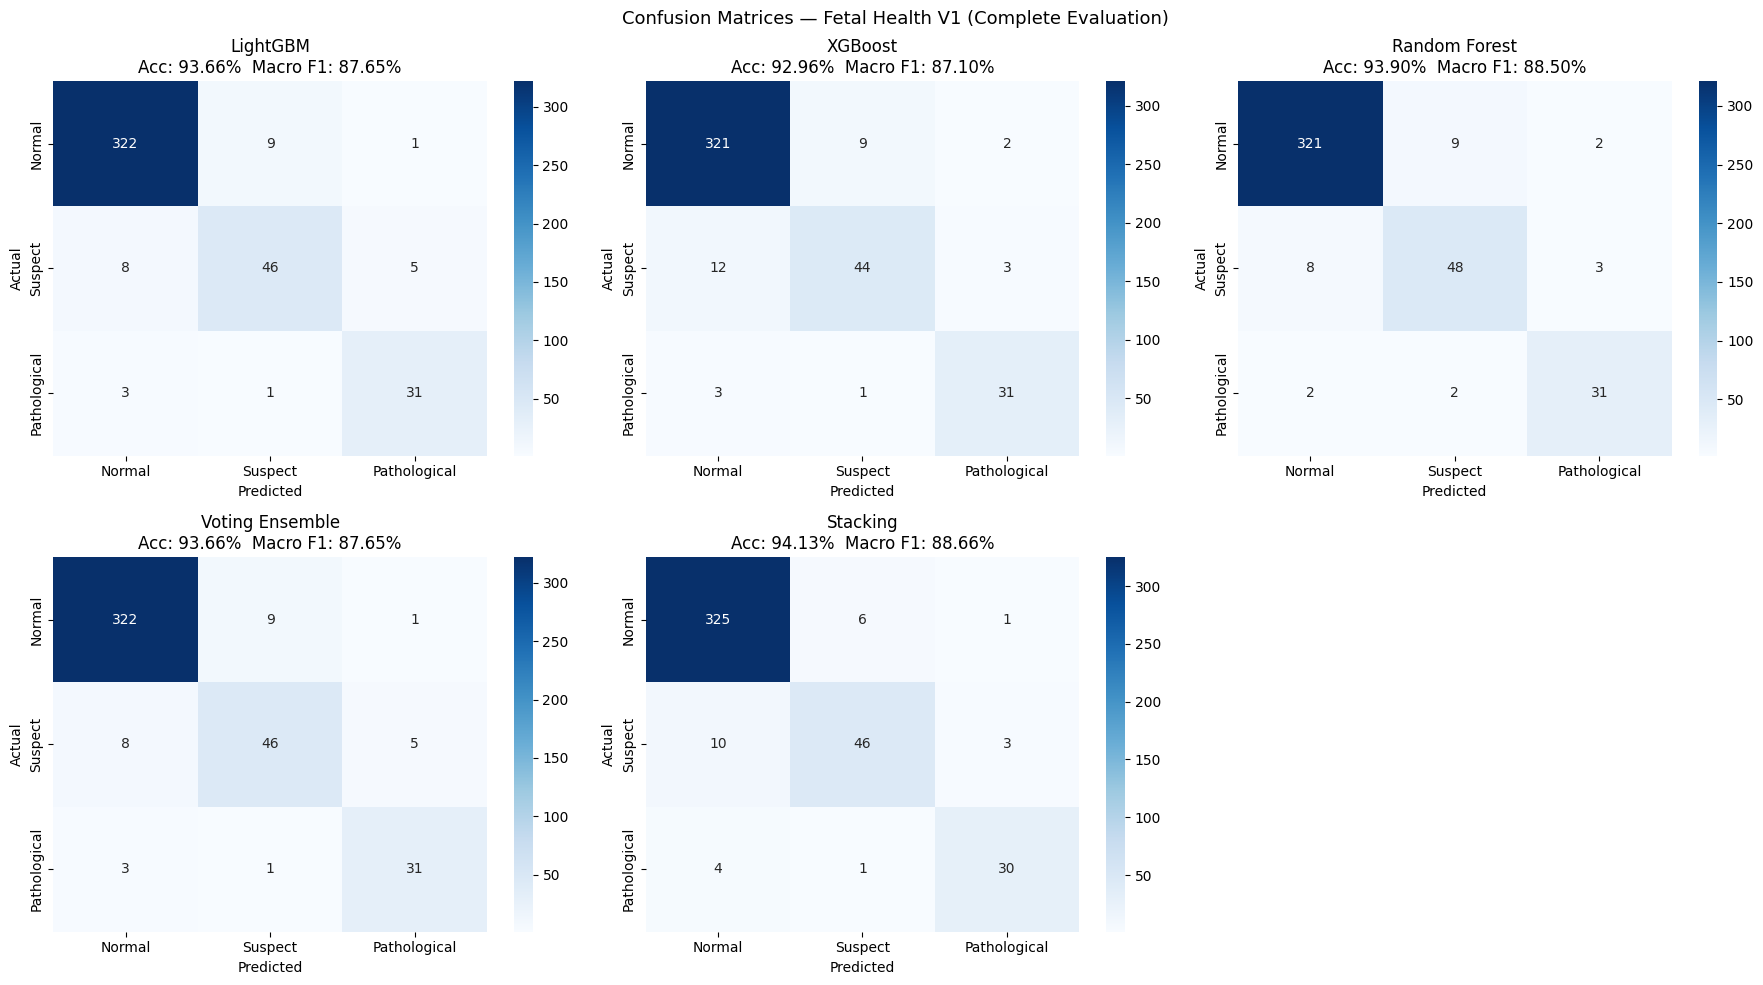

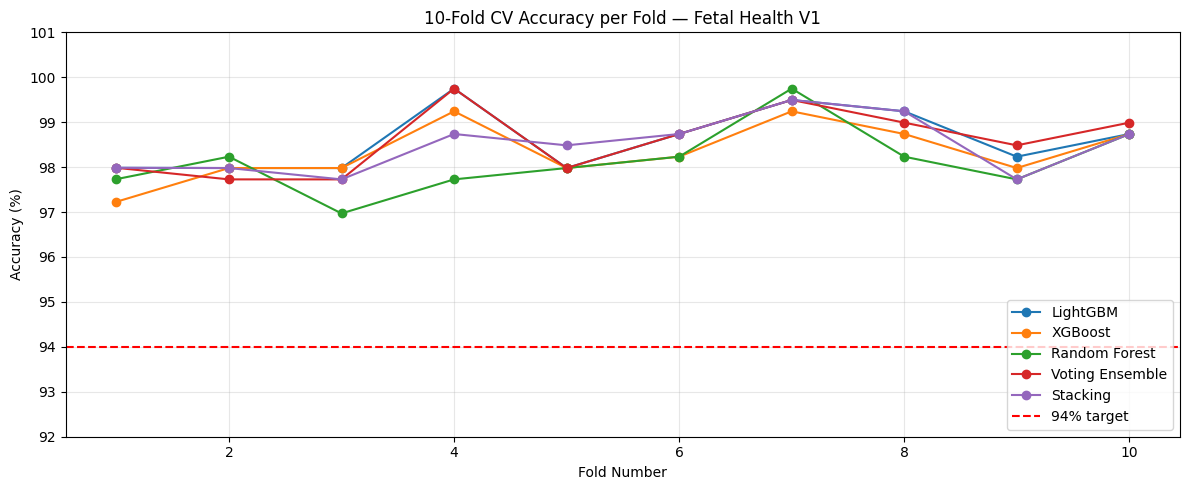


Complete evaluation done!


In [20]:
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score,
                             precision_score, recall_score)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*70)
print("COMPLETE MEDICAL ML EVALUATION — Fetal Health V1")
print("="*70)

models_eval = {
    "LightGBM":        (lgb_best,     pred_lgb,     lgb_cv10),
    "XGBoost":         (xgb_best,     pred_xgb,     xgb_cv10),
    "Random Forest":   (rf_best,      pred_rf,      rf_cv10),
    "Voting Ensemble": (voting_clf,   pred_voting,  voting_cv10),
    "Stacking":        (stacking_clf, pred_stacking,stacking_cv10),
}

class_names = ["Normal", "Suspect", "Pathological"]

# ── Summary Table ──
print(f"\n{'Model':<20} {'Accuracy':>9} {'Macro F1':>9} {'Macro P':>9} "
      f"{'Macro R':>9} {'CV Mean':>9} {'CV Std':>9}")
print("-"*76)

for name, (model, pred, cv_scores) in models_eval.items():
    acc    = accuracy_score(y_test, pred)
    mac_f1 = f1_score(y_test, pred, average="macro")
    mac_p  = precision_score(y_test, pred, average="macro")
    mac_r  = recall_score(y_test, pred, average="macro")
    cv_mean = cv_scores.mean()
    cv_std  = cv_scores.std()

    print(f"{name:<20} {acc*100:>8.2f}% {mac_f1*100:>8.2f}% "
          f"{mac_p*100:>8.2f}% {mac_r*100:>8.2f}% "
          f"{cv_mean*100:>8.2f}% {cv_std*100:>8.2f}%")

# ── Per Class Breakdown for Best Model (Stacking) ──
print("\n" + "="*70)
print("PER CLASS METRICS — Stacking Ensemble (Best Model)")
print("="*70)
print(f"\n{'Class':<15} {'Precision':>10} {'Recall':>10} {'F1 Score':>10} {'Support':>10}")
print("-"*50)

p_scores = precision_score(y_test, pred_stacking, average=None)
r_scores = recall_score(y_test, pred_stacking, average=None)
f_scores = f1_score(y_test, pred_stacking, average=None)
supports = [sum(y_test == i) for i in range(3)]

for i, cls in enumerate(class_names):
    print(f"{cls:<15} {p_scores[i]*100:>9.2f}% {r_scores[i]*100:>9.2f}% "
          f"{f_scores[i]*100:>9.2f}% {supports[i]:>10}")

print(f"\n{'Macro Avg':<15} {p_scores.mean()*100:>9.2f}% "
      f"{r_scores.mean()*100:>9.2f}% {f_scores.mean()*100:>9.2f}%")
print(f"{'Weighted Avg':<15} "
      f"{precision_score(y_test, pred_stacking, average='weighted')*100:>9.2f}% "
      f"{recall_score(y_test, pred_stacking, average='weighted')*100:>9.2f}% "
      f"{f1_score(y_test, pred_stacking, average='weighted')*100:>9.2f}%")

# ── CV Mean ± Std for all models ──
print("\n" + "="*70)
print("CROSS VALIDATION MEAN ± STD (10-Fold)")
print("="*70)
print(f"\n{'Model':<20} {'CV Mean':>10} {'CV Std':>10} {'Min Fold':>10} {'Max Fold':>10}")
print("-"*55)

for name, (model, pred, cv_scores) in models_eval.items():
    print(f"{name:<20} {cv_scores.mean()*100:>9.2f}% "
          f"{cv_scores.std()*100:>9.2f}%  "
          f"{cv_scores.min()*100:>9.2f}%  "
          f"{cv_scores.max()*100:>9.2f}%")

# ── Confusion Matrices ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (name, (model, pred, cv)) in zip(axes.flatten(), models_eval.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    acc    = accuracy_score(y_test, pred)
    mac_f1 = f1_score(y_test, pred, average="macro")
    ax.set_title(f"{name}\nAcc: {acc*100:.2f}%  Macro F1: {mac_f1*100:.2f}%")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

axes[1][2].set_visible(False)
plt.suptitle("Confusion Matrices — Fetal Health V1 (Complete Evaluation)",
             fontsize=13)
plt.tight_layout()
plt.savefig("fetal_complete_evaluation.png")
plt.show()

# ── CV Distribution Plot ──
fig, ax = plt.subplots(figsize=(12, 5))
for name, (model, pred, cv_scores) in models_eval.items():
    ax.plot(range(1, 11), cv_scores * 100, marker="o", label=name)

ax.axhline(y=94, color="red", linestyle="--", linewidth=1.5, label="94% target")
ax.set_xlabel("Fold Number")
ax.set_ylabel("Accuracy (%)")
ax.set_title("10-Fold CV Accuracy per Fold — Fetal Health V1")
ax.legend(loc="lower right")
ax.set_ylim(92, 101)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fetal_cv_distribution.png")
plt.show()

print("\nComplete evaluation done!")